<h1 align="center">ASSIGNMENT 1</h1>
<h2 align="center">Intelligent Data Analysis</h2>
<h2 align="center">DV1597</h2>
<h3 align="center">Group 9</h3>
<h3 align="center">Grace Dona Harlita Tarihoran (grta26@student.bth.se)</h3>

# Introduction

The dataset used is gathered by the Swedish Meteorological and Hydrological Institute (SMHI) and consists of official air temperature measures from the city of Karlskrona between 2010-03-01 (00:00 UTC) – 2025-01-01 (06:00 UTC). The dataset is available as a CSV file.

<h3 align="left"> Key objectives:</h3>

1. Data Loading: importing a dataset from an external file to a suitable data structure
2. Data Cleaning (preprocessing): handling various data cleaning tasks, such as missing values
3. Data Transformation (wrangling): aggregating the data in various ways
4. Exploratory Data Analysis: performing data-driven analyses to answer questions
5. Data Visualization: create graphical plots

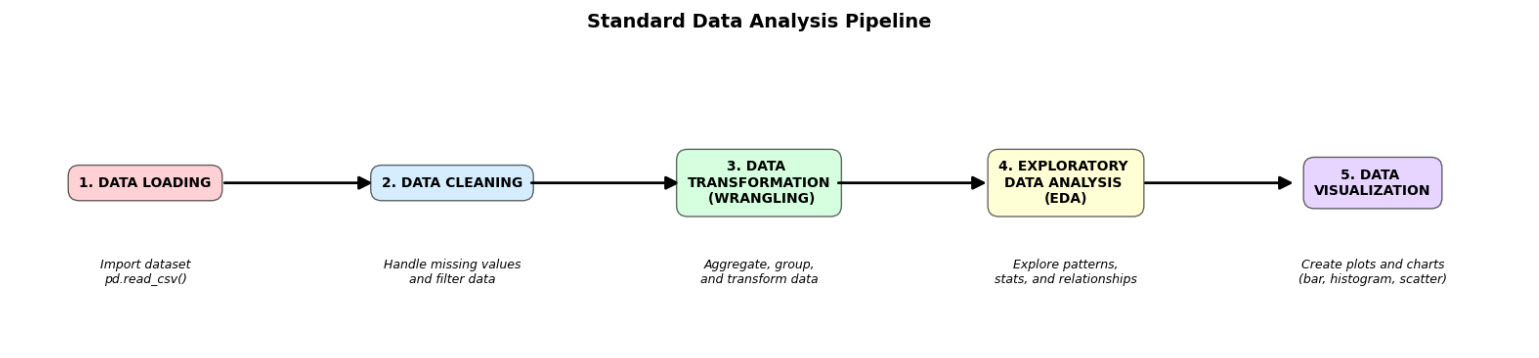

## Q1. Load, explore, and clean the dataset

<h4 align="center"> Inspect → Structure → Remove errors → Handle missing → Prepare for analysis</h4>

### Load and inspect the dataset

The dataset was loaded from `SMHI_Data.csv` using pandas. An initial data check was conducted to understand the structure and quality of the dataset. This included examining the dataset shape, column names and types, missing values, duplicate rows, and basic descriptive statistics.

In [108]:
# import pandas library for data manipulation and analysis
import pandas as pd

# load dataset and save it as a dataframe 
# Original raw dataset
df = pd.read_csv("SMHI_Data.csv")

# Display the first 5 rows of data
print("The first 5 rows of data")
print(df.head())

# Display data size (row, column)
print("\nDataset shape:", df.shape)

# Display columns datatype
print("\nDataset information:")
df.info()

# Check duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

# Display if there are missing values
print("\nMissing values:")
print(df.isna().sum())

# Display descriptive statisctic of data
print("\nDescriptive Statisctic:")
print(df.describe())

The first 5 rows of data
        Datum Tid (UTC)  Lufttemperatur
0  2010-03-01  08:00:00             0.8
1  2010-03-01  09:00:00             1.0
2  2010-03-01  10:00:00             1.0
3  2010-03-01  11:00:00             0.7
4  2010-03-01  12:00:00             1.5

Dataset shape: (131717, 3)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131717 entries, 0 to 131716
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Datum           131717 non-null  object 
 1   Tid (UTC)       131717 non-null  object 
 2   Lufttemperatur  123961 non-null  float64
dtypes: float64(1), object(2)
memory usage: 3.0+ MB

Duplicate rows:
2443

Missing values:
Datum                0
Tid (UTC)            0
Lufttemperatur    7756
dtype: int64

Descriptive Statisctic:
       Lufttemperatur
count   123961.000000
mean         9.466281
std          6.974073
min        -20.100000
25%          4.100000
50%          9.

#### Initial data overview:
1. **Shape**: the dataset contains of 131,717 rows and 3 columns.
2. **Dataset information**: column names are `Datum`, `Tid (UTC)`, and `Lufttemperatur`. The date and time columns are stored as object data types, while the air temperature column is stored as a numerical float value.
   > The dataset represents **time-series data**, as each observation corresponds to air temperature measurements recorded at specific dates and times.

3. **Missing values**: column `Lufttemperatur` contains 7,756 (5.89%) missing values. These values should be handled before continuing with further analysis.
4. **Duplicate rows**: 2,443 (1.85%) duplicate rows were identified.
5. **Descriptive statistics**: the recorded air temperature ranges from -20.1°C to 39.4°C, with an average temperature of approximately 9.47°C.

### Convert date and time into a datetime column

The columns `Datum` and `Tid (UTC)` are stored as text/ object values.</br>
Since this is time-series temperature data, they should be combined into one `Datetime` column with datetime data type.

### Remove duplicate rows

The dataset contains duplicate rows. Removing duplicates is important because repeated observations can bias the analysis and visualizations.

### Handle missing temperature values

Missing values are found only in `Lufttemperatur`.</br>
Since temperature is the main variable for analysis, rows with missing temperature values should not be used for statistical calculations.

### Sort data by datetime

Since the dataset is time-series, sorting the data ensures that line plots and time-series analysis are shown in the correct order.

### Check possible outliers

Outliers should be inspected using descriptive statistics and plots such as boxplots. Values should not be removed automatically unless if these points correspond to measurement error.</br>

The steps are applied in this order to ensure a logical data preparation process.</br>

1. First, the dataset is inspected to identify issues.</br>
2. Then, date and time are combined to enable time-series analysis.</br>
3. Duplicate rows are removed early to avoid bias, followed by handling missing values to ensure data quality.</br>
4. The data is then sorted chronologically, and finally, outliers are checked.</br>


**This sequence ensures that the dataset is clean, consistent, and ready for analysis.**

In [109]:
# Create cleaned version
df_cleaned = df.copy()

# Convert date and time into a datetime column
df_cleaned["Datetime"] = pd.to_datetime(
    df_cleaned["Datum"] + " " + df_cleaned["Tid (UTC)"]
)

# Remove missing values
df_cleaned = df_cleaned.dropna(subset=["Lufttemperatur"])

# Remove duplicate rows
df_cleaned = df_cleaned.drop_duplicates()

# Sort data by datetime
df_cleaned = df_cleaned.sort_values("Datetime")

print("Data cleaning process is completed.")

Data cleaning process is completed.


## Q2. Missing values proportion

The dataset contains missing values only in the `Lufttemperatur` column.

Total rows: 131,717</br>
Missing values in Lufttemperatur: 7,756</br>
Percentage missing: 5.89%

The dataset contains 7,756 missing air temperature values, which is approximately 5.89% of the dataset. The proportion of missing values is relatively **low**, but it is still important because air temperature is the main variable used in the analysis. Therefore, the missing values should be handled carefully before calculating statistics or creating visualizations.

## Q3. Missing values handling

The selected strategy is to **remove rows where air temperature is missing.**

`Lufttemperatur` is the main variable of interest in this analysis.
Since the proportion of missing values is **relatively low** (approximately 5.89%), removing these rows with missing values is unlikely affect the overall analysis significantly. This strategy is also simple, transparent, and avoids introducing artificial temperature values through imputation.

## Q4. `Lufttemperatur` statistics

The descriptive statistics of `Lufttemperatur` column after removing duplicate rows and missing values:

In [110]:
# Import NumPy for numerical calculations, such as square root
import numpy as np

# Import the stats module from SciPy for statistical calculations
import scipy.stats as stats

# Select the air temperature column from the cleaned dataset
temp = df_cleaned["Lufttemperatur"]

# Calculate the minimum air temperature value
min_value = temp.min()

# Calculate the maximum air temperature value
max_value = temp.max()

# Calculate the first quartile (Q1 / 25th percentile)
q1 = temp.quantile(0.25)

# Calculate the second quartile (Q2 / median / 50th percentile)
q2 = temp.quantile(0.50)

# Calculate the third quartile (Q3 / 75th percentile)
q3 = temp.quantile(0.75)

# Calculate the sample mean of the air temperature values
mean = temp.mean()

# Calculate the sample standard deviation of the air temperature values
# Standard deviation was calculated using ddof=1 to apply Bessel’s correction
# which provides an unbiased estimate when working with sample data.
std = temp.std(ddof=1)

# Count the number of non-missing air temperature values
n = temp.count()

# Calculate the standard error of the mean
se = std / np.sqrt(n)

# Calculate the 95% confidence interval of the mean using the t-distribution
ci_95 = stats.t.interval(
    confidence=0.95,  # Set the confidence level to 95%
    df=n-1,           # Set the degrees of freedom to sample size minus 1
    loc=mean,         # Set the center of the interval to the sample mean
    scale=se          # Set the scale to the standard error, se = std / √n
)

# Display the results with 2 decimal places
print(f"Minimum: {min_value:.2f}")
print(f"Maximum: {max_value:.2f}")
print(f"Q1: {q1:.2f}")
print(f"Q2 / Median: {q2:.2f}")
print(f"Q3: {q3:.2f}")
print(f"Mean: {mean:.2f}")
print(f"Std Dev: {std:.2f}")
print(f"95% CI: [{ci_95[0]:.2f}, {ci_95[1]:.2f}]")

Minimum: -20.10
Maximum: 39.40
Q1: 4.10
Q2 / Median: 9.10
Q3: 15.30
Mean: 9.46
Std Dev: 6.98
95% CI: [9.42, 9.50]


## Q5. Line plot for `Lufttemperatur`

The line plot shows the available air temperature observations over time. The x-axis represents the date and time, while the y-axis represents air temperature in degrees Celsius.

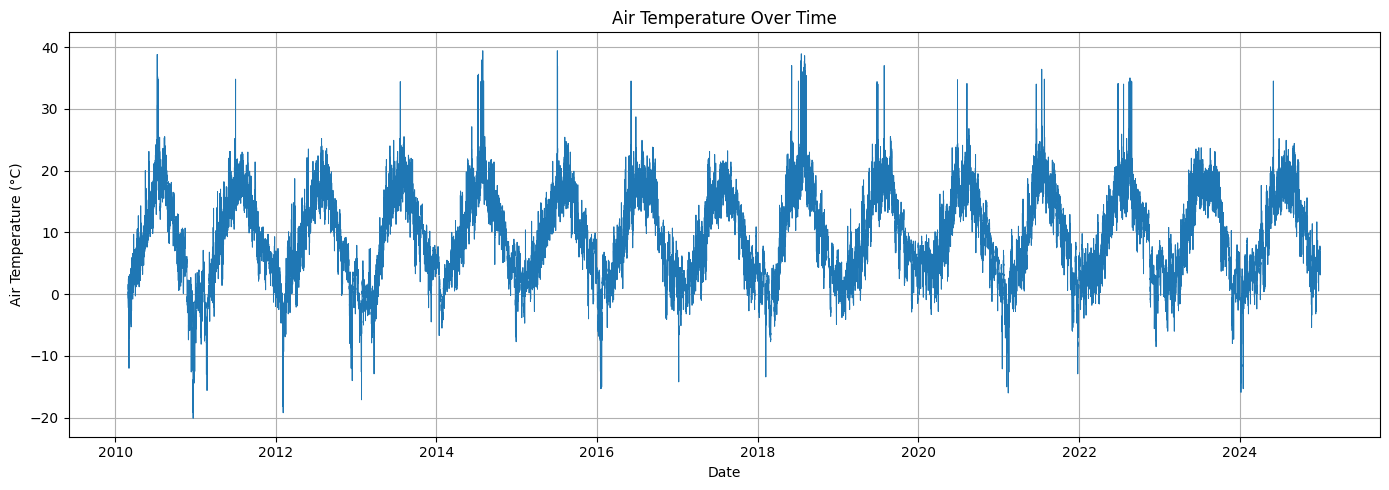

In [111]:
# Import matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Create a new figure and set the size of the plot
plt.figure(figsize=(14, 5))

# Create a line plot using Datetime on the x-axis and air temperature on the y-axis
plt.plot(
    df_cleaned["Datetime"],        # X-axis: date and time values
    df_cleaned["Lufttemperatur"],  # Y-axis: air temperature values
    linewidth=0.7                  # Set the line thickness
)

# Add a title to the plot
plt.title("Air Temperature Over Time")

# Add a label to the x-axis
plt.xlabel("Date")

# Add a label to the y-axis
plt.ylabel("Air Temperature (°C)")

# Add grid lines to make the plot easier to read
plt.grid(True)

# Adjust the layout so labels and titles fit properly
plt.tight_layout()

# Display the plot
plt.show()

**Observation**:

- The line plot of `Lufttemperatur` displays a repetitive, wave-like pattern over time</br>
- Data points reach their lowest values at the beginning and end of each annual cycle (Winter) and peak in the middle of each cycle (Summer)</br>
- High-frequency "noise" or jagged edges are visible representing daily temperature variations</br>

**Interpretation**:

- The line plot of `Lufttemperatur` shows a clear **seasonal pattern** in the air temperature data, confirming that air temperature is primarily driven by annual climate cycles</br>
- The peak values align with the expected summer solstice periods, while the troughs align with winter</br>
- The plot also shows daily fluctuations, indicating that temperature changes from day to day even within the same season

## Q6. Top ten (10) coldest months in the dataset

**How to find the coldest months in the data:**

1. Calculate the mean air temperature for each month in each year, the result will look like this:
    > - 2010/March had an average temperature of 0.47°C
    > - 2010/April had an average temperature of 5.98°C
    > - 2010/May had an average temperature of 9.65°C
    > - .....
   
3. Sort the monthly mean temperatures from the lowest to the highest.
4. Select the first 10 rows from the sorted result.
5. Format the output as YEAR/Month: temperature.

In [112]:
# Extract year, month number, and month name from the Datetime column
df_cleaned["Year"] = df_cleaned["Datetime"].dt.year
df_cleaned["Month"] = df_cleaned["Datetime"].dt.month
df_cleaned["MonthName"] = df_cleaned["Datetime"].dt.month_name()

# Calculate the average air temperature for each year and month
monthly_temp = (
    df_cleaned.groupby(["Year", "Month", "MonthName"])["Lufttemperatur"]
    .mean()
    .reset_index()
)

# Sort from coldest to warmest and select the top 10 coldest months
coldest_months = monthly_temp.sort_values("Lufttemperatur").head(10)

# Print the result in the required format
for _, row in coldest_months.iterrows():
    print(f"{int(row['Year'])}/{row['MonthName']}: {row['Lufttemperatur']:.2f}")

2010/December: -3.79
2011/February: -1.51
2012/February: -1.34
2016/January: -1.04
2021/February: -0.98
2018/February: -0.91
2013/March: -0.84
2013/January: -0.66
2012/December: -0.61
2011/January: -0.45


## Q7. Checking normality of air temperature data

The distribution of the air temperature data was examined **to better understand its characteristics and to assess whether it follows a normal distribution**. This step is important because many statistical methods assume that the data is normally distributed.

A normal distribution was considered as a candidate due to the continuous nature of the air temperature data.

### Air temperature histogram

A histogram of the air temperature data was plotted and compared with a fitted normal distribution curve.

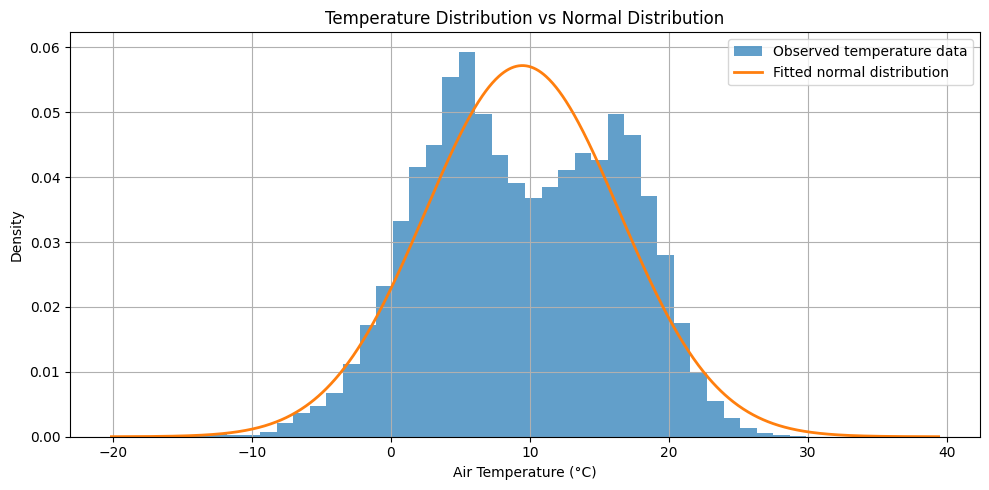

In [113]:
# Import libraries
from scipy.stats import norm

# Select the air temperature column
temp = df_cleaned["Lufttemperatur"]

# Fit a normal distribution to the temperature data
mu, sigma = norm.fit(temp)

# Create figure
plt.figure(figsize=(10, 5))

# Plot histogram of the actual temperature data
plt.hist(
    temp,
    bins=50,
    density=True,
    alpha=0.7,
    label="Observed temperature data"
)

# Create x values from minimum to maximum temperature
x = np.linspace(temp.min(), temp.max(), 1000)

# Calculate the normal distribution curve using fitted mean and std
pdf = norm.pdf(x, mu, sigma)

# Plot the fitted normal distribution curve
plt.plot(
    x,
    pdf,
    linewidth=2,
    label="Fitted normal distribution"
)

# Add title and axis labels
plt.title("Temperature Distribution vs Normal Distribution")
plt.xlabel("Air Temperature (°C)")
plt.ylabel("Density")

# Add legend and grid
plt.legend()
plt.grid(True)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

**Observations:**

- The histogram of observed temperature data (blue bars) shows two distinct peaks (one near 5°C and another near 17°C) rather than a single central peak</br>
- There is a significant "dip" or valley in the data frequency around 10°C</br>
- The orange line (fitted normal distribution) peaks in the center where the actual data frequency is low, and it fails to capture the two actual peaks of the dataset</br>
- The temperatures span from approximately -10°C to 30°C, with very few occurrences outside this range

**Interpretation:**

- The histogram shows that the distribution of air temperature does not show normal distribution as the curve</br>
- The two peaks represent the most common temperature states in this region: the left peak likely represents colder (winter/early spring) months, and the right peak represents warmer (summer) months</br>
- The dip at 10°C suggests that "middle" temperatures occur less frequently, as the weather tends to transition relatively quickly through these temperatures between the summer and winter states

### Implementing Kolmogorov–Smirnov test
To evaluate how well the data fits this distribution, a Kolmogorov–Smirnov (KS) test was performed. The KS statistic measures the maximum difference between the observed data and the theoretical normal distribution. 

**The Kolmogorov–Smirnov (KS) test** was chosen because:

- it compares the observed data with a theoretical distribution</br>
- provides a quantitative measure of how well the data fits that distribution (p-value) which allows us to statistically decide whether the data follows a normal distribution</br>
- air temperature is a continuous variable, and the KS test is suitable for continuous data

In [114]:
# Fit normal distribution
#mu: estimated mean
#sigma: estimated standard deviation
mu, sigma = stats.norm.fit(temp)

# KS test
ks_stat, p_value = stats.kstest(temp, "norm", args=(mu, sigma))

print("KS statistic:", ks_stat)
print("p-value:", p_value)

KS statistic: 0.05444738789700937
p-value: 1.50270319075e-313


**Observation**:

- The KS statistic is 0.0544</br>
- The p-value is $1.5027 \times 10^{-313}$ (extremely close to zero)</br>
  
**Interpretation:**

- Rejecting the Null Hypothesis: Because the p-value is significantly lower than the standard alpha level (e.g., 0.05), the null hypothesis that the data follows a normal distribution must be rejected</br>
- Non-Normality: This confirms that the air temperature data does not follow a normal distribution</br>
- Contextual Reason: The deviation is likely caused by seasonal variations (winter vs. summer), which create the two peaks seen in histogram, making the distribution asymmetric and non-Gaussian</br>

**This Kolmogorov-Smirnov test ($p < 0.05$) supports the histogram result, which mathematically rejected the assumption of normality.**

## Q8. Check extreme values/ outliers

### Air temperature boxplot

**A boxplot** was used to visually identify potential outliers in the air temperature data. Values outside the whiskers (lower and upper bound) are considered potential outliers according to the **IQR method**.

How to calculate with IQR method:

1. Sort the data
2. Identifying the 25th (Q1) and 75th (Q3) percentiles
3. Compute the difference between Q3 and Q1  to get the interquartile range (IQR)
4. Based on the IQR method, outliers were defined as values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR

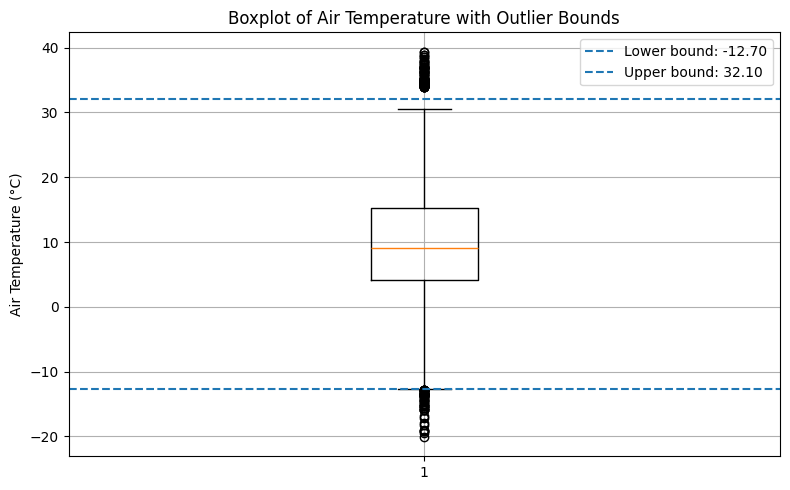

In [115]:
# Calculate IQR
# We have calculate q1 and q3 before in Q4 code
iqr = q3 - q1

# Calculate lower and upper outlier bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Create boxplot
plt.figure(figsize=(8, 5))

plt.boxplot(
    df_cleaned["Lufttemperatur"],
    vert=True
)

# Add horizontal lines for outlier boundaries
plt.axhline(lower_bound, linestyle="--", label=f"Lower bound: {lower_bound:.2f}")
plt.axhline(upper_bound, linestyle="--", label=f"Upper bound: {upper_bound:.2f}")

# Add title and labels
plt.title("Boxplot of Air Temperature with Outlier Bounds")
plt.ylabel("Air Temperature (°C)")

# Add legend and grid
plt.legend()
plt.grid(True)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

### Implementing IQR method in the dataset

The result of calculating IQR in the dataset:

Q1 = 4.10</br>
Q3 = 15.30

IQR = Q3 − Q1</br>
     = 15.30 − 4.10</br>
     = 11.20

Lower bound = Q1 − 1.5 × IQR</br>
    = 4.10 − 1.5 (11.20)</br>
    = -12.70

Upper bound = Q3 + 1.5 × IQR</br>
            = 15.30 + 1.5 (11.20)</br>
            = 32.10

**Outliers:**</br>
Temperature < -12.70°C; </br>
Temperature > 32.10°C


**Observation:**

- The dataset identifies 157 total outliers</br>
- There are 63 values falling below the lower bound of -12.70°C</br>
- There are 94 values falling above the upper bound of 32.10°C</br>
- The frequency of extreme heat outliers (above the upper bound) is approximately 1.5 times higher than extreme cold outliers

**Interpretation:**

- Potential outliers found in the air temperature data **considered anomalies**</br>
- Since these outliers exist, they contribute to the non-Gaussian (non-normal) nature of the distribution</br>
- The higher number of upper outliers suggests that **unusually high temperatures may be more frequent** than extremely low temperatures in the observed period

## Q9. Daily mean temperature in 2024

The mean air temperature was calculated for each day in 2024 by grouping the data by date and computing the average temperature for each day. The daily means were then visualized using a line plot with dates on the x-axis.

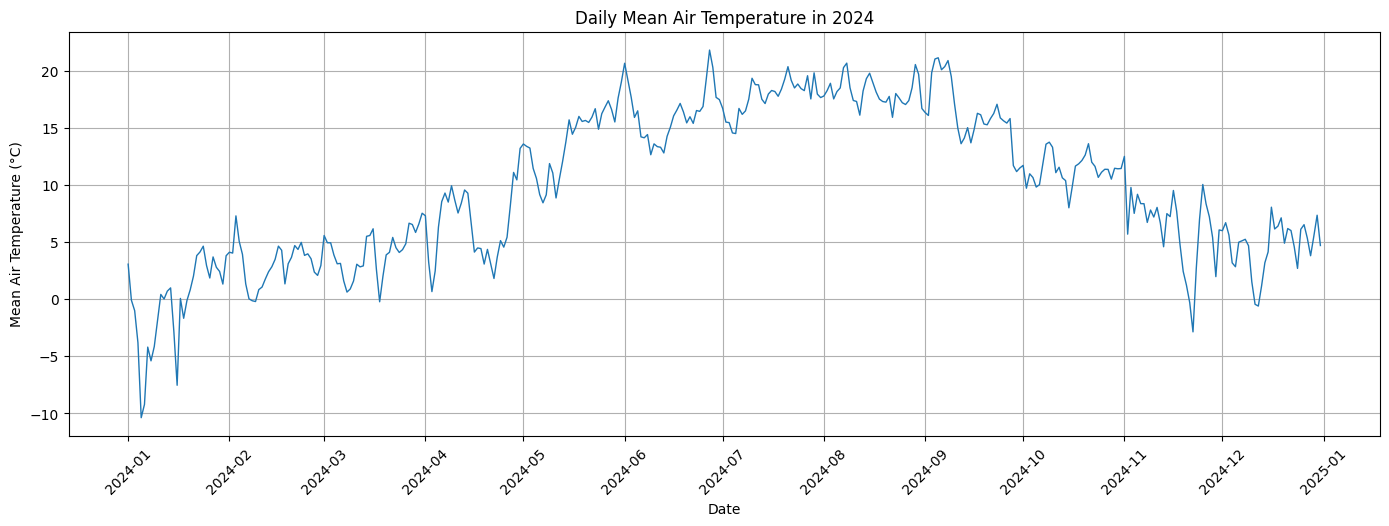

In [116]:
# Import matplotlib.dates to show every month on the x-axis:
import matplotlib.dates as mdates

# Select data from the year 2024
df_2024 = df_cleaned[df_cleaned["Datetime"].dt.year == 2024].copy()

# Extract only the date from the Datetime column
df_2024["Date"] = df_2024["Datetime"].dt.date

# Calculate the mean air temperature for each day
daily_mean_2024 = (
    df_2024.groupby("Date")["Lufttemperatur"]
    .mean()
    .reset_index()
)

# Create figure
plt.figure(figsize=(14, 5))

# Create line plot of daily mean temperature in 2024
plt.plot(
    daily_mean_2024["Date"],
    daily_mean_2024["Lufttemperatur"],
    linewidth=1
)

# Set the x-axis to show one tick for each month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) 
# Format the x-axis labels as Year-Month, e.g., 2024-01
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m")) 

# Add title and labels
plt.title("Daily Mean Air Temperature in 2024")
plt.xlabel("Date")
plt.ylabel("Mean Air Temperature (°C)")

# Add grid
plt.grid(True)

# Adjust layout
plt.tight_layout()

# Rotate x-axis labels by 45 degrees to improve readability
plt.xticks(rotation=45)

# Show plot
plt.show()

**Observation:**

- The plot shows a clear bell-shaped arch across the year, with the lowest troughs in January (reaching below -10°C) and the highest peaks in June/July (exceeding 20°C)</br>
- While the seasonal trend is smooth, the daily line is "jagged," showing significant short-term fluctuations where temperature can drop or rise by several degrees within days</br>
- The rise appears from April to June</br>
- The gradual decline observed from September to November

**Interpretation:**

- The line plot shows a clear **seasonal pattern** in the daily mean air temperature in 2024</br>
- Temperatures are **lowest at the beginning and end of the year (winter)**</br>
- Gradually increase toward the middle of the year, reaching **a peak during summer months**</br>
- Afterward, the temperature decreases again toward winter

<h3 align="center">Data Analytics Pipeline</h3>

<h4 align="center">Data Loading -> Data Cleaning -> Exploratory Data Analysis (EDA) -> Visualization</h4>

## Q10. Top ten (10) warmest 2-months in the dataset

**How we find the warmest 2-months in the data:**

1. Calculate monthly average temperature, the result will look like this:</br>
    2010-03-01    0.47</br>
    2010-04-01    5.98</br>
    2010-05-01    9.65</br>
    
   2010: March → December = 10 months</br>
   2011 → 2023: 13 full years = 13 × 12 = 156 months</br>
   2024: January → December = 12 months</br>

   Total = 178 months
   
2. Calculate average of two consecutive months, the result will look like this:</br>
    March-April mean = (March mean + April mean) / 2</br>
    April-May mean = (April mean + May mean) / 2</br>

    Number of consecutive pairs = total months − 1</br>
    Total = 178 - 1 = 177 months

    From: 2010/March-April</br>
    To: 2024/November-December
   
3. Create period label</br>
   2010/March-April</br>
   2010/April-May</br>
   2010/May-June
   
4. Sort all 2-month periods from highest average temperature to lowest
5. Select the first 10 rows from the sorted result
6. Print the result as YEAR/Month1-Month2: temperature.

In [83]:
# Calculate monthly mean temperature
monthly_temp = (
    df_cleaned
    .set_index("Datetime")
    .resample("MS")["Lufttemperatur"] # MS means Month Start, so each month is represented by its first day
    .mean()
    .reset_index()
)

# Calculate rolling 2-month average
monthly_temp["TwoMonthMean"] = (
    monthly_temp["Lufttemperatur"]
    .rolling(window=2)
    .mean()
)

# Create period label, e.g., 2010/July-August
monthly_temp["Period"] = (
    monthly_temp["Datetime"].dt.strftime("%Y/%B") 
    + "-" +
    monthly_temp["Datetime"].shift(-1).dt.strftime("%B") # shift(-1) gets the next month name.
)

# Shift rolling result so the average belongs to the starting month
# By default, rolling average is placed on the second month
# This line moves it so the average is placed on the first month
monthly_temp["TwoMonthMean"] = monthly_temp["TwoMonthMean"].shift(-1)

# Remove rows without complete 2-month period
two_month_periods = monthly_temp.dropna(subset=["TwoMonthMean", "Period"])

# Sort from warmest to coldest and select top 10
warmest_two_months = (
    two_month_periods
    .sort_values("TwoMonthMean", ascending=False)
    .head(10)
)

# Print results
for _, row in warmest_two_months.iterrows():
    print(f"{row['Period']}: {row['TwoMonthMean']:.2f}")

2018/July-August: 20.91
2018/June-July: 19.86
2021/June-July: 19.52
2014/July-August: 19.33
2010/July-August: 18.85
2021/July-August: 18.67
2022/July-August: 18.56
2019/July-August: 18.34
2013/July-August: 18.27
2014/June-July: 18.14


## Q11. Daily Mean Air Temperature in 2024 with 95% Confidence Intervals

**How the daily mean air temperature in 2024 with 95% CI was calculated:**

1. Filter the dataset to include only observations from the year 2024 (as done in Q9)
2. Extract the date from the Datetime column (as done in Q9)
3. Group the data by date (as done in Q9)
4. Calculate the daily mean, standard deviation, and number of observations
5. Compute the standard error for each day
6. Calculate the lower and upper bounds of the 95% confidence interval for each day
7. Plot the daily mean temperature with the confidence interval shown as a shaded area
   
Notes:

- The 95% confidence interval was calculated using the sample mean, standard deviation, and sample size for each day</br>
- The degrees of freedom (df) were calculated as n−1 for each day</br>
- The corresponding t-value was obtained from the t-distribution based on the degrees of freedom and a 95% confidence level

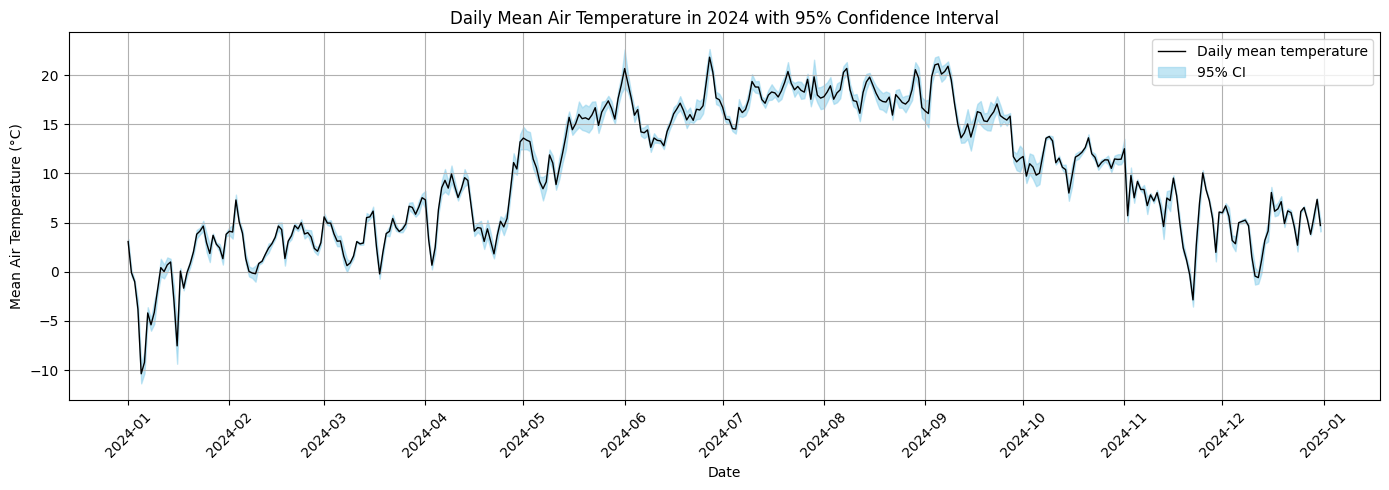

In [98]:
# Calculate daily mean, standard deviation, and number of observations
daily_stats_2024 = (
    df_2024.groupby("Date")["Lufttemperatur"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Calculate standard error
daily_stats_2024["se"] = daily_stats_2024["std"] / np.sqrt(daily_stats_2024["count"])

# Calculate t-value for 95% confidence interval
daily_stats_2024["t_value"] = daily_stats_2024["count"].apply(
    lambda n: stats.t.ppf(0.975, df=n-1)
)

# Calculate lower and upper CI bounds
daily_stats_2024["ci_lower"] = daily_stats_2024["mean"] - daily_stats_2024["t_value"] * daily_stats_2024["se"]
daily_stats_2024["ci_upper"] = daily_stats_2024["mean"] + daily_stats_2024["t_value"] * daily_stats_2024["se"]

# Convert Date to datetime format for plotting
daily_stats_2024["Date"] = pd.to_datetime(daily_stats_2024["Date"])

# Plot daily mean with 95% confidence interval
plt.figure(figsize=(14, 5))

plt.plot(
    daily_stats_2024["Date"],
    daily_stats_2024["mean"],
    color="black",
    label="Daily mean temperature",
    linewidth=1
)

plt.fill_between(
    daily_stats_2024["Date"],
    daily_stats_2024["ci_lower"],
    daily_stats_2024["ci_upper"],
    color='skyblue',
    alpha=0.5,
    label="95% CI"
)

# Show every month on x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.title("Daily Mean Air Temperature in 2024 with 95% Confidence Interval")
plt.xlabel("Date")
plt.ylabel("Mean Air Temperature (°C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

- The line plot shows a clear seasonal pattern in daily mean air temperature throughout 2024</br>
- The shaded area helps show how much variation exists around the daily mean</br>
-  Wider shaded areas indicate greater uncertainty or variability in the temperature observations for that day, while narrower shaded areas indicate more stable daily temperature values

**Interpretation:**

- The plot shows a clear seasonal pattern</br>
- Temperatures are lower during winter months in the beginning of the year, increase toward the middle of the year, and then decrease again toward the end of the year
- The Confidence Intervals (CI) provide information about the uncertainty of the estimated daily mean

# Conclusion

In conclusion, this study demonstrates how data cleaning, statistical analysis, and visualization can be effectively combined to extract meaningful insights from time-series data.</br> 

The results highlight clear seasonal temperature patterns and show that the estimated daily means are reliable, as supported by the confidence intervals. These findings emphasize the importance of proper data preparation and statistical methods in data analysis.

# References

1. Skiena, S. S. (2017). The data science design manual. Springer.
2. Cady, Field. (2017). The data science handbook. Wiley.
3. Matplotlib Development Team. (2026). Matplotlib documentation. https://matplotlib.org/stable/index.html